In [ ]:
!unzip /content/'Airplane Crashes and Fatalities upto 2023'.zip


Archive:  /content/Airplane Crashes and Fatalities upto 2023.zip
  inflating: Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv  


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer



#Importation et nettoyage des données
df = pd.read_csv('/content/Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv', encoding='latin1')
df.head()


,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,9/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,7/12/1912,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,8/6/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,9/9/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...


In [41]:
f"Shape of the dataset : {df.shape}"

airplane = df.copy()
airplane.drop_duplicates()

#Décompte et calcul du pourcentage des données manquantes
missing_count = airplane.isnull().sum()
missing_pct = (missing_count * 100 / len(airplane))
missing_df = pd.DataFrame({'missing_count': missing_count, 'missing_pct': missing_pct})
missing_df.sort_values(by='missing_pct', ascending=False)

cols_to_drop = missing_df[missing_df["missing_pct"] > 50].index

airplane_new = airplane.drop(columns=cols_to_drop)

#Traitement des valeurs manquantes des variables numériques
num_cols = airplane_new.select_dtypes(include=np.number).columns

for col in num_cols:
    airplane_new[col] = airplane_new[col].fillna(airplane_new[col].median())

#Traitement des valeurs des variables catégorielles
cat_cols = airplane_new.select_dtypes(include="object").columns

for col in cat_cols:
    airplane_new[col] = airplane_new[col].fillna(airplane_new[col].mode()[0])


#conversion des dates
airplane_new["Date"] = pd.to_datetime(airplane_new["Date"])
airplane_new["Year"] =airplane_new["Date"].dt.year
airplane_new["Month"] = airplane_new["Date"].dt.month
airplane_new["Decade"] = (airplane_new["Year"] // 10) * 10

airplane_new.head()


,Date,Time,Location,Operator,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary,Year,Month,Decade
0,1908-09-17,17:18,"Fort Myer, Virginia",Military - U.S. Army,Demonstration,Wright Flyer III,19,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly...",1908,9,1900
1,1909-09-07,15:00,"Juvisy-sur-Orge, France",Aeroflot,Air show,Wright Byplane,SC1,1,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...,1909,9,1900
2,1912-07-12,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,Test flight,Dirigible,19,1,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...,1912,7,1910
3,1913-08-06,15:00,"Victoria, British Columbia, Canada",Private,Training,Curtiss seaplane,19,1,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...,1913,8,1910
4,1913-09-09,18:30,Over the North Sea,Military - German Navy,Training,Zeppelin L-1 (airship),19,1,20.0,12.0,4.0,14.0,8.0,3.0,0.0,The airship flew into a thunderstorm and encou...,1913,9,1910


Analyse exploratoire des données

In [51]:
#Nombre total d'accidents
total_accidents = len(airplane_new)
print(f"Nombre total d'accidents : {total_accidents}")

#Nombre total des décès
total_deaths = airplane_new["Fatalities"].sum()
print(f"Nombre total des décès : {total_deaths}")

#Taux de survie
airplane_new["survival_rate"] = (
    (airplane_new["Aboard"] - airplane_new["Fatalities"]) / airplane_new["Aboard"]
) * 100
print(f"Taux de survie : {airplane_new['survival_rate'].mean():.2f}%")


Nombre total d'accidents : 4998
Nombre total des décès : 111732.0
Taux de survie : 18.23%


Analyse de la fréquence des incidents

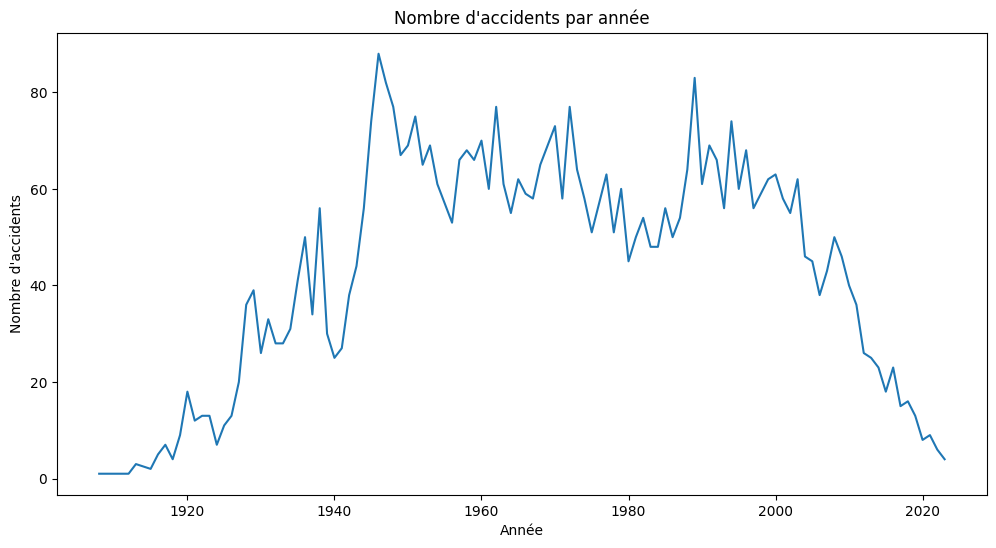

In [58]:
accidents_year = airplane_new.groupby("Year").size()

plt.figure(figsize=(12,6))

accidents_year.plot()

plt.title("Nombre d'accidents par année")
plt.xlabel("Année")
plt.ylabel("Nombre d'accidents")

plt.show()

Analyse statistique des distributions avec SciPy

In [47]:
#Distribution des décès
  #Calcul des statistiques clées des décès
fatalities = airplane_new["Fatalities"]
fatalities.mean()
fatalities.median()
fatalities.std()

fatalities.describe()

,Fatalities
count,4998.000000
mean,22.355342
std,35.036614
min,0.000000
25%,4.000000
50%,11.000000
75%,25.000000
max,583.000000


In [53]:
#Distribution du taux de survie
survival_rate = airplane_new["survival_rate"]

survival_rate.describe()

,survival_rate
count,4993.000000
mean,18.229929
std,31.221170
min,-62.500000
25%,0.000000
50%,0.000000
75%,25.000000
max,100.000000


In [59]:
#Test d'hypothèse : comparer le nombre moyen de décès au cours de différentes décennies
old = airplane_new[airplane_new["Decade"] < 1980]["Fatalities"]

recent = airplane_new[airplane_new["Decade"] >= 1980]["Fatalities"]

t_stat, p_value= stats.ttest_ind(old, recent, equal_var=False)

print("t =", t_stat)
print("p =", p_value)

t = -5.761696102247421
p = 9.188952622805861e-09


Visualisation

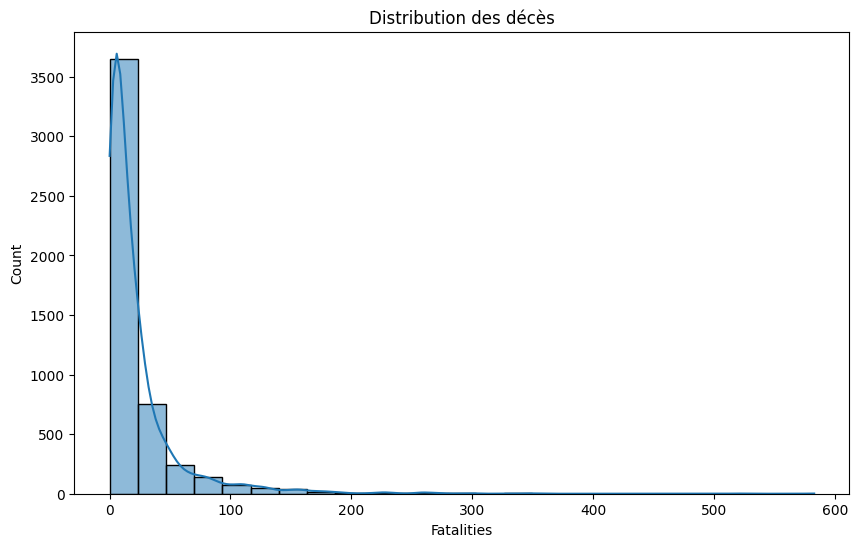

In [63]:
#Histogramme des décès
plt.figure(figsize=(10,6))

sns.histplot(
    airplane_new["Fatalities"],
    bins=25,
    kde=True
)

plt.title("Distribution des décès")

plt.show()

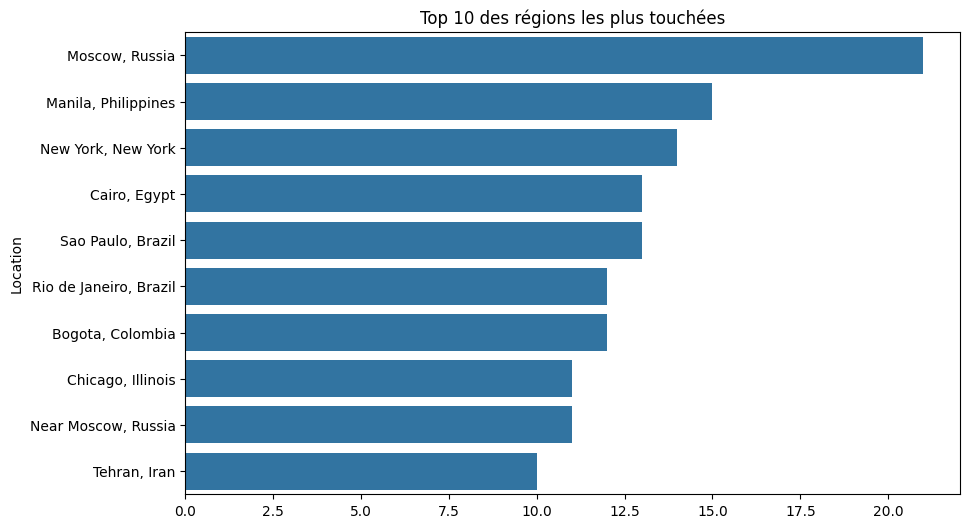

In [64]:
#Accidents par région
accidents_count = (airplane_new["Location"].value_counts().head(10))

plt.figure(figsize=(10,6))

sns.barplot(
    x=accidents_count.values,
    y=accidents_count.index
)

plt.title("Top 10 des régions les plus touchées")

plt.show()

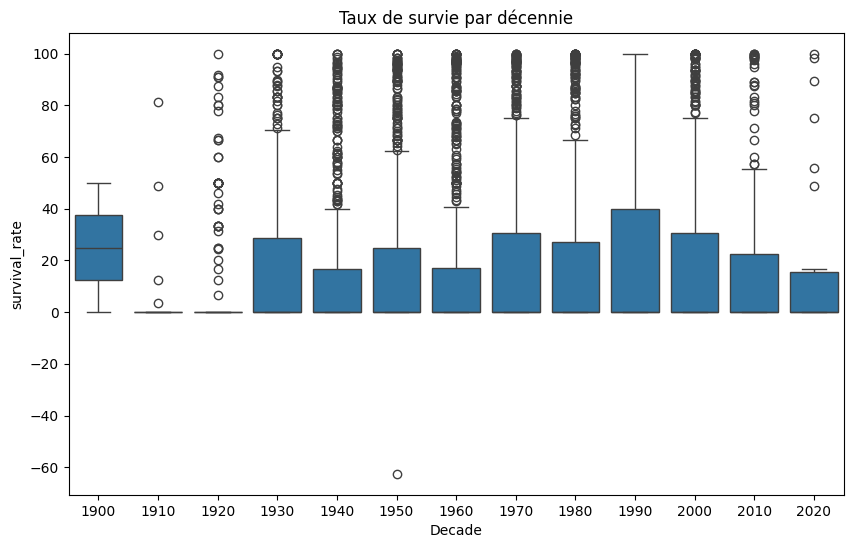

In [65]:
#Taux de srvie par décennie
plt.figure(figsize=(10,6))

sns.boxplot(
    x=airplane_new["Decade"],
    y=airplane_new["survival_rate"]
)

plt.title("Taux de survie par décennie")

plt.show()


Analyse :

Principaux résultats
Le dataset contient 4998 accidents aériens enregistrés.
Le nombre total de décès est de 111732.
Les accidents étaient plus fréquents entre 1940 et 1950.
Une diminution progressive des accidents est observable après les années 1990.
Le taux de survie moyen est de 18.23%.
Les décès présentent une forte dispersion (écart-type élevé).
Le test statistique montre une différence significative entre les décennies étudiées.

Cocnclusion :
L'analyse met en évidence une évolution importante de la sécurité aérienne au fil du temps. Bien que certains accidents aient causé un nombre élevé de décès, la tendance globale suggère une amélioration progressive des standards de sécurité et une réduction du risque au cours des dernières décennies.

# Utilisation des bibliothèques :

*Pandas :*

* Chargement des données
* Nettoyage
* Agrégation
* Création de variables

*NumPy*

* Calculs numériques
* Manipulation des tableaux

*SciPy*

* Tests statistiques
* Analyse des distributions


*Matplotlib & Seaborn*
* Visualisation des
* tendances
* Histogrammes
* Diagrammes en barres
* Séries temporelles

In [67]:
!cp /content/drive/MyDrive/Colab Notebooks/DailyChallenge (1).ipynb /content/drive/MyDrive/TTA-Bootcamp-GenAI/Week2/Day3/DailyChallenge

/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `cp /content/drive/MyDrive/Colab Notebooks/DailyChallenge (1).ipynb /content/drive/MyDrive/TTA-Bootcamp-GenAI/Week2/Day3/DailyChallenge'
